In [1]:
import pandas as pd
from build_utils import get_universalization_summary, get_outcome_metrics, build_design_matrix
from analysis_utils import regression_xy, plot_simple_regression, compare_models, fit_ols

OUTCOME_COLS = [
    "aggregate_welfare",
    "inequality",
    "cardinal_harm",
    "ordinal_harm_blind",
    "gini",
]
UNIV_COLS = [f"univ_{c}" for c in OUTCOME_COLS]

In [2]:
# Retrieve per-scenario outcome metrics
out = get_outcome_metrics(recompute=False) # set to True to rebuild from completion times

# Retrieve experimental data
xp_file = "cross_cultural_pilot_summary.csv"
xp = pd.read_csv(f"../data/experimental/{xp_file}")

In [3]:
# For every run type, retrieve summary per-map universalization metrics,
# and build regression-ready design matrix
RUN_TYPES = ["kwon2023", "level-0", "level-1, level-0-by-noise"]

univ_by_run = {}
design_by_run = {}

for run_type in RUN_TYPES:
    univ_by_run[run_type] = get_universalization_summary(run_type=run_type, recompute=False)
    design_by_run[run_type] = build_design_matrix(univ_by_run[run_type], out, xp)

In [4]:
# --- Best model exploration --- #

In [5]:
# Best model using only outcome measures (from actual line-cutting scenarios seen by participants)
summary_baseline = compare_models(design_by_run["kwon2023"], predictors=OUTCOME_COLS, run_type="N/A", dv="rating_mean")
summary_baseline

# Best model is simple regression with aggregate_welfare (R2=.629; BIC=64.6).

# Second best: AW + OH. (R2=.636; BIC=67.6) [NB: OH by itself is super bad, it explains less thant 3% of variance]
# Next: AW + Ineq, AW + Gini, AW + CH, CH only [CH is systematically the second best predictor for simple reg]

# Kwon2023 model, with four outcome variables (not gini) gives you marginally higher correlation (R2 += .035), and is penalized (BIC += 11)

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,N/A,0.629469,0.619455,61.299306,64.626429,39,aggregate_welfare
7,2,AW+OH,N/A,0.636171,0.615958,62.587446,67.578131,39,aggregate_welfare+ordinal_harm_blind
5,2,AW+Ineq,N/A,0.630512,0.609985,63.189425,68.180110,39,aggregate_welfare+inequality
8,2,AW+Gini,N/A,0.629938,0.609379,63.249888,68.240573,39,aggregate_welfare+gini
6,2,AW+CH,N/A,0.629642,0.609067,63.281087,68.271772,39,aggregate_welfare+cardinal_harm
2,1,CH,N/A,0.580424,0.569084,66.147305,69.474429,39,cardinal_harm
18,3,AW+CH+OH,N/A,0.651751,0.621901,62.880532,69.534778,39,aggregate_welfare+cardinal_harm+ordinal_harm_b...
16,3,AW+Ineq+OH,N/A,0.638742,0.607777,64.310833,70.965079,39,aggregate_welfare+inequality+ordinal_harm_blind
20,3,AW+OH+Gini,N/A,0.637690,0.606635,64.424276,71.078523,39,aggregate_welfare+ordinal_harm_blind+gini
17,3,AW+Ineq+Gini,N/A,0.630650,0.598992,65.174775,71.829022,39,aggregate_welfare+inequality+gini


In [37]:
# Best model using aggregate welfare (best outcome-only model) and univeralization measures from kwon2023
summary_kwon2023 = compare_models(design_by_run["kwon2023"], predictors=["aggregate_welfare"]+UNIV_COLS, run_type="kwon2023", dv="rating_mean")
summary_kwon2023

# Best model adds just univ_aggregate welfare (R2 = .714, BIC = 58.1)
# Second best: add U_AW and U_CH (R2 =.731, BIC=59.5)
# (Next: add U_AW and U_Gini / U_AW and U_Ineq / or just U_CH)

# U_AW alone: R2= 0.381760	 / BIC= 84.592110	
# Then U_CH 

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
6,2,AW+U_AW,kwon2023,0.714412,0.698546,53.144180,58.134865,39,aggregate_welfare+univ_aggregate_welfare
22,3,AW+U_AW+U_CH,kwon2023,0.730805,0.707731,52.838782,59.493028,39,aggregate_welfare+univ_aggregate_welfare+univ_...
24,3,AW+U_AW+U_Gini,kwon2023,0.722019,0.698192,54.091323,60.745570,39,aggregate_welfare+univ_aggregate_welfare+univ_...
21,3,AW+U_AW+U_Ineq,kwon2023,0.721530,0.697661,54.159923,60.814170,39,aggregate_welfare+univ_aggregate_welfare+univ_...
8,2,AW+U_CH,kwon2023,0.693524,0.676498,55.897172,60.887857,39,aggregate_welfare+univ_cardinal_harm
...,...,...,...,...,...,...,...,...,...
16,2,U_Ineq+U_OH,kwon2023,0.199780,0.155323,93.327375,98.318060,39,univ_inequality+univ_ordinal_harm_blind
39,3,U_Ineq+U_OH+U_Gini,kwon2023,0.266732,0.203880,91.919733,98.573980,39,univ_inequality+univ_ordinal_harm_blind+univ_gini
5,1,U_Gini,kwon2023,0.066758,0.041535,97.324702,100.651825,39,univ_gini
4,1,U_OH,kwon2023,0.007411,-0.019416,99.729142,103.056265,39,univ_ordinal_harm_blind


In [55]:
# Best model using all outcome metrics and all univeralization measures from kwon2023
summary_kwon2023_full = compare_models(design_by_run["kwon2023"], predictors=OUTCOME_COLS+ UNIV_COLS, run_type="kwon2023", dv="rating_mean")
summary_kwon2023_full.head(10)
#summary_kwon2023_full[ summary_kwon2023_full [ "n_predictors" ] == 1]
# Overall, best model remains AW + U_AW
# Next (close): CH + U_AW + U_CH / AW + U_AW + U_CH (BIC+1)

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,kwon2023,0.629469,0.619455,61.299306,64.626429,39,aggregate_welfare
2,1,CH,kwon2023,0.580424,0.569084,66.147305,69.474429,39,cardinal_harm
5,1,U_AW,kwon2023,0.381760,0.365051,81.264987,84.592110,39,univ_aggregate_welfare
4,1,Gini,kwon2023,0.346767,0.329112,83.412199,86.739322,39,gini
7,1,U_CH,kwon2023,0.291209,0.272052,86.595660,89.922783,39,univ_cardinal_harm
6,1,U_Ineq,kwon2023,0.182211,0.160109,92.174343,95.501466,39,univ_inequality
9,1,U_Gini,kwon2023,0.066758,0.041535,97.324702,100.651825,39,univ_gini
1,1,Ineq,kwon2023,0.040803,0.014879,98.394542,101.721665,39,inequality
3,1,OH,kwon2023,0.028557,0.002302,98.889281,102.216405,39,ordinal_harm_blind
8,1,U_OH,kwon2023,0.007411,-0.019416,99.729142,103.056265,39,univ_ordinal_harm_blind


In [53]:
# Best model using aggregate welfare (best outcome-only model) and univeralization measures from level-0
summary_lvl_0 = compare_models(design_by_run["level-0"], predictors=["aggregate_welfare"]+UNIV_COLS, run_type="level-0", dv="rating_mean")
summary_lvl_0 [ summary_lvl_0[ "n_predictors" ]==1 ]
#summary_lvl_0 
# Best model adds just univ_aggregate welfare (R2 = .722, BIC = 57.1)
# Second best: add U_AW and U_Ineq (R2 =.741, BIC=58)
# (Next: add U_AW and U_CH / U_AW and U_Gini / or just U_CH)

# U_AW alone: R2=35.6, BIC=86.2
# U_CH alone: R2=23.8, BIC=91.7 / Ineq ok / Gini small /  OH ridiculous

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,level-0,0.629469,0.619455,61.299306,64.626429,39,aggregate_welfare
1,1,U_AW,level-0,0.356533,0.339142,82.824743,86.151866,39,univ_aggregate_welfare
3,1,U_CH,level-0,0.258296,0.238249,88.365859,91.692982,39,univ_cardinal_harm
2,1,U_Ineq,level-0,0.169212,0.146758,92.789405,96.116528,39,univ_inequality
5,1,U_Gini,level-0,0.062992,0.037668,97.481753,100.808876,39,univ_gini
4,1,U_OH,level-0,0.018208,-0.008327,99.302592,102.629715,39,univ_ordinal_harm_blind


In [9]:
# Best model using all outcome metrics and all univeralization measures from level-0
summary_lvl_0_full = compare_models(design_by_run["level-0"], predictors=OUTCOME_COLS+UNIV_COLS, run_type="level-0", dv="rating_mean")
summary_lvl_0_full.head(10)

# Best model is still AW+U_AW
# Second best (very close, BIC+.8): AW+U_AW+U_Ineq
# Next: AW+U_AW+U_CH / AW+U_AW+U_Gini/ CH+U_AW+U_CH (BIC increase <= 1.5)

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
14,2,AW+U_AW,level-0,0.721737,0.706278,52.130849,57.121534,39,aggregate_welfare+univ_aggregate_welfare
81,3,AW+U_AW+U_Ineq,level-0,0.741183,0.718998,51.305562,57.959808,39,aggregate_welfare+univ_aggregate_welfare+univ_...
82,3,AW+U_AW+U_CH,level-0,0.737540,0.715044,51.850565,58.504812,39,aggregate_welfare+univ_aggregate_welfare+univ_...
84,3,AW+U_AW+U_Gini,level-0,0.736110,0.713491,52.062563,58.716810,39,aggregate_welfare+univ_aggregate_welfare+univ_...
131,3,CH+U_AW+U_CH,level-0,0.735088,0.712381,52.213266,58.867513,39,cardinal_harm+univ_aggregate_welfare+univ_card...
16,2,AW+U_CH,level-0,0.700828,0.684207,54.956513,59.947198,39,aggregate_welfare+univ_cardinal_harm
58,3,AW+Ineq+U_AW,level-0,0.727482,0.704123,53.317237,59.971483,39,aggregate_welfare+inequality+univ_aggregate_we...
83,3,AW+U_AW+U_OH,level-0,0.722597,0.698819,54.010195,60.664441,39,aggregate_welfare+univ_aggregate_welfare+univ_...
71,3,AW+OH+U_AW,level-0,0.722593,0.698815,54.010727,60.664973,39,aggregate_welfare+ordinal_harm_blind+univ_aggr...
76,3,AW+Gini+U_AW,level-0,0.722397,0.698603,54.038209,60.692456,39,aggregate_welfare+gini+univ_aggregate_welfare


In [54]:
# Best model using aggregate welfare (best outcome-only model) and univeralization measures from level-0
summary_lvl_1 = compare_models(design_by_run["level-1"], predictors=["aggregate_welfare"]+UNIV_COLS, run_type="level-1", dv="rating_mean")
summary_lvl_1 
summary_lvl_1 [summary_lvl_1 ["n_predictors"]==1]
# Best model adds just univ_aggregate welfare (R2 = .718, BIC = 57.6)
# Second best: add U_AW and U_Ineq (R2 =.733, BIC=59.1)
# (Next: add U_AW and U_Gini / U_AW and U_GCH / or just U_CH)

# U_AW alone: 37.2%, BIC=85.2
# U_CH alone: 

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,level-1,0.629469,0.619455,61.299306,64.626429,39,aggregate_welfare
1,1,U_AW,level-1,0.372141,0.355171,81.867116,85.194239,39,univ_aggregate_welfare
3,1,U_CH,level-1,0.287040,0.267771,86.824343,90.151466,39,univ_cardinal_harm
2,1,U_Ineq,level-1,0.173106,0.150758,92.606144,95.933267,39,univ_inequality
5,1,U_Gini,level-1,0.046272,0.020496,98.171529,101.498652,39,univ_gini
4,1,U_OH,level-1,0.031991,0.005829,98.751183,102.078306,39,univ_ordinal_harm_blind


In [11]:
# Best model using all outcome metrics and all univeralization measures from level-1
summary_lvl_1_full = compare_models(design_by_run["level-1"], predictors=OUTCOME_COLS+UNIV_COLS, run_type="level-1", dv="rating_mean")
summary_lvl_1_full.head(10)

# Best model is still AW+U_AW
# Next: AW+U_AW+U_Ineq / W+U_AW+U_Gini / AW+U_AW+U_CH / AW+U_AW+U_CH	 (1.5 <= BIC increase <= 2)

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
14,2,AW+U_AW,level-1,0.718028,0.702363,52.647226,57.637911,39,aggregate_welfare+univ_aggregate_welfare
81,3,AW+U_AW+U_Ineq,level-1,0.733459,0.710612,52.452398,59.106644,39,aggregate_welfare+univ_aggregate_welfare+univ_...
84,3,AW+U_AW+U_Gini,level-1,0.729695,0.706526,52.999204,59.653450,39,aggregate_welfare+univ_aggregate_welfare+univ_...
82,3,AW+U_AW+U_CH,level-1,0.729573,0.706394,53.016797,59.671044,39,aggregate_welfare+univ_aggregate_welfare+univ_...
16,2,AW+U_CH,level-1,0.700125,0.683466,55.047975,60.038660,39,aggregate_welfare+univ_cardinal_harm
131,3,CH+U_AW+U_CH,level-1,0.725673,0.702159,53.575293,60.229540,39,cardinal_harm+univ_aggregate_welfare+univ_card...
58,3,AW+Ineq+U_AW,level-1,0.723563,0.699868,53.874110,60.528356,39,aggregate_welfare+inequality+univ_aggregate_we...
71,3,AW+OH+U_AW,level-1,0.719242,0.695177,54.478947,61.133193,39,aggregate_welfare+ordinal_harm_blind+univ_aggr...
76,3,AW+Gini+U_AW,level-1,0.718721,0.694612,54.551245,61.205491,39,aggregate_welfare+gini+univ_aggregate_welfare
83,3,AW+U_AW+U_OH,level-1,0.718331,0.694188,54.605349,61.259595,39,aggregate_welfare+univ_aggregate_welfare+univ_...


In [12]:
# - Draft ln likehood stuff

In [13]:
from scipy import stats

def lr_test(m_small, m_big):
    """
    Likelihood-ratio test for nested OLS models.
    m_small: restricted model
    m_big:   full model (includes all predictors in m_small)

    Returns: (statistic, df, p_value)
    """
    ll_small = m_small.llf
    ll_big = m_big.llf

    # number of parameters (including intercept) is len(.params)
    k_small = len(m_small.params)
    k_big = len(m_big.params)
    df = k_big - k_small

    if df <= 0:
        raise ValueError("m_big must have more parameters than m_small.")

    stat = 2 * (ll_big - ll_small)
    p = stats.chi2.sf(stat, df)
    return stat, df, p


In [14]:
design = design_by_run["kwon2023"]

# 1) AW
row_aw, m_aw = fit_ols(design, ["aggregate_welfare"], dv="rating_mean", run_type="level-1")

# 2) AW + U_AW
row_aw_uaw, m_aw_uaw = fit_ols(
    design,
    ["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_type="level-1",
)

# 3) AW + U_AW + U_Ineq
row_aw_uaw_uineq, m_aw_uaw_uineq = fit_ols(
    design,
    ["aggregate_welfare", "univ_aggregate_welfare", "univ_inequality"],
    dv="rating_mean",
    run_type="level-1",
)

# LR tests
print("AW vs AW+U_AW:", lr_test(m_aw, m_aw_uaw))
print("AW+U_AW vs AW+U_AW+U_Ineq:", lr_test(m_aw_uaw, m_aw_uaw_uineq))

# For all 3 run types: adding U_AW is significantly better; Adding U_Ineq after doesn't significantly improve the model

AW vs AW+U_AW: (np.float64(10.155125527325502), 1, np.float64(0.00143900597352762))
AW+U_AW vs AW+U_AW+U_Ineq: (np.float64(0.984257202259549), 1, np.float64(0.32115002673823334))


In [15]:
# --- Draft: model comparison for small subset, with ln-likelihood column

In [27]:
import pandas as pd

design0 = design_by_run["level-0"]

models_lvl0 = {}

# M0: AW
row_M0, m_M0 = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M0_AW"] = (row_M0, m_M0)

# M1: AW + U_AW
row_M1, m_M1 = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M1_AW+U_AW"] = (row_M1, m_M1)

# M2a: AW + U_AW + U_Ineq
row_M2a, m_M2a = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_inequality"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M2a_AW+U_AW+U_Ineq"] = (row_M2a, m_M2a)

# M2b: AW + U_AW + U_CH
row_M2b, m_M2b = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_cardinal_harm"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M2b_AW+U_AW+U_CH"] = (row_M2b, m_M2b)

# M2c: AW + U_AW + U_Gini
row_M2c, m_M2c = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_gini"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M2c_AW+U_AW+U_Gini"] = (row_M2c, m_M2c)

# Put rows in a DataFrame
rows = []
for name, (row, model) in models_lvl0.items():
    r = row.copy()
    r["model_id"] = name
    r["logLik"] = model.llf
    rows.append(r)

tbl_lvl0 = pd.DataFrame(rows)

# Add ΔBIC relative to best
best_bic = tbl_lvl0["BIC"].min()
tbl_lvl0["delta_BIC"] = tbl_lvl0["BIC"] - best_bic

# Add LR tests:
# - M0 vs M1
# - M1 vs each M2*
tbl_lvl0["lr_ref"] = None
tbl_lvl0["lr_stat"] = None
tbl_lvl0["lr_df"] = None
tbl_lvl0["lr_p"] = None

def set_lr_row(df, model_from, model_to, ref_name):
    stat, df_lr, p = lr_test(models_lvl0[model_from][1],
                             models_lvl0[model_to][1])
    idx = df["model_id"] == model_to
    df.loc[idx, "lr_ref"] = ref_name
    df.loc[idx, "lr_stat"] = stat
    df.loc[idx, "lr_df"] = df_lr
    df.loc[idx, "lr_p"] = p

# AW vs AW+U_AW
set_lr_row(tbl_lvl0, "M0_AW", "M1_AW+U_AW", ref_name="M0_AW")

# AW+U_AW vs each 3-predictor model
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2a_AW+U_AW+U_Ineq", ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2b_AW+U_AW+U_CH",   ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2c_AW+U_AW+U_Gini", ref_name="M1_AW+U_AW")

# For display: pick columns & order
cols = [
    "model_id",
    "predictors",           # your short labels, e.g. AW+U_AW
    "n_predictors",
    "R2",
    "adj_R2",
    "AIC",
    "BIC",
    "delta_BIC",
    "lr_ref",
    "lr_stat",
    "lr_df",
    "lr_p",
]
tbl_lvl0_display = tbl_lvl0[cols].sort_values("BIC")

# Pull out M0 row
m0 = tbl_lvl0_display[tbl_lvl0_display["model_id"] == "M0_AW"]
rest = tbl_lvl0_display[tbl_lvl0_display["model_id"] != "M0_AW"]

# Recombine with M0 first
tbl_lvl0_display = pd.concat([m0, rest], ignore_index=True)
tbl_lvl0_display


,model_id,predictors,n_predictors,R2,adj_R2,AIC,BIC,delta_BIC,lr_ref,lr_stat,lr_df,lr_p
0,M0_AW,AW,1,0.629469,0.619455,61.299306,64.626429,7.504895,None,None,None,None
1,M1_AW+U_AW,AW+U_AW,2,0.721737,0.706278,52.130849,57.121534,0.000000,M0_AW,11.168457,1,0.000832
2,M2a_AW+U_AW+U_Ineq,AW+U_AW+U_Ineq,3,0.741183,0.718998,51.305562,57.959808,0.838275,M1_AW+U_AW,2.825287,1,0.09279
3,M2b_AW+U_AW+U_CH,AW+U_AW+U_CH,3,0.737540,0.715044,51.850565,58.504812,1.383278,M1_AW+U_AW,2.280284,1,0.131028
4,M2c_AW+U_AW+U_Gini,AW+U_AW+U_Gini,3,0.736110,0.713491,52.062563,58.716810,1.595276,M1_AW+U_AW,2.068286,1,0.150391


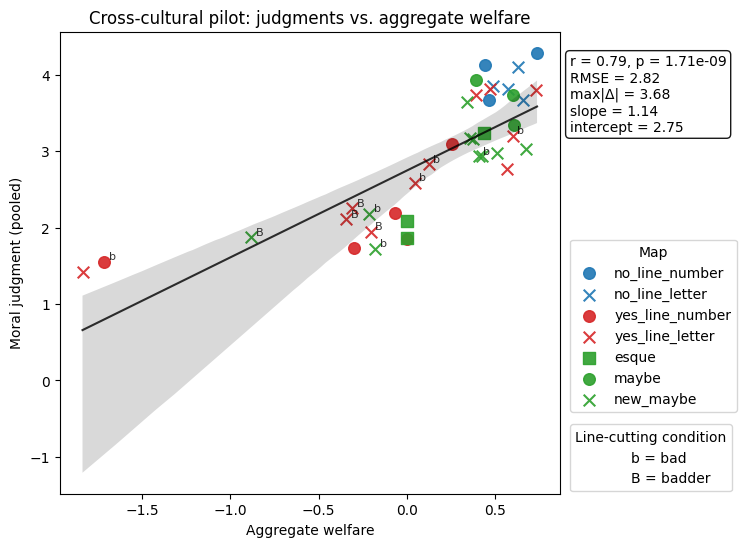

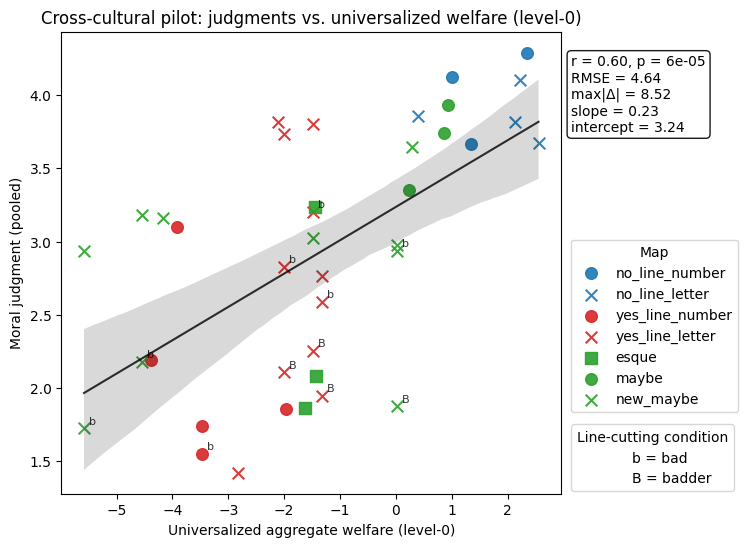

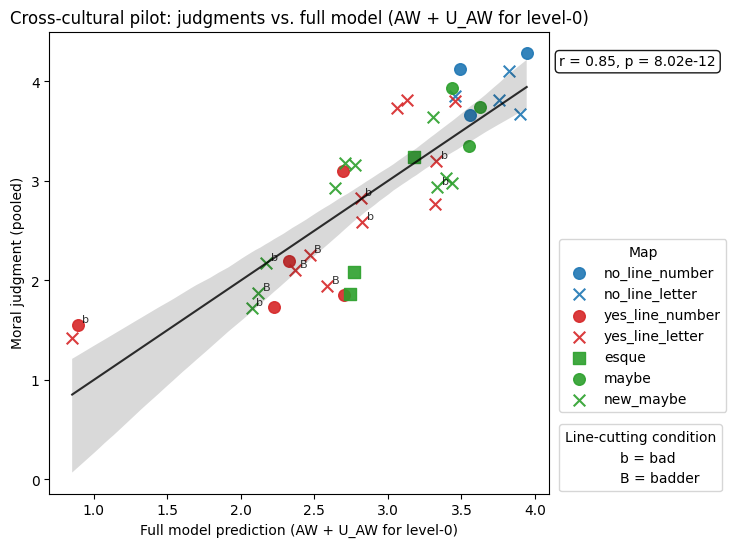

In [28]:
# --- Draft: make figure 5 style plots 

# Add predictions to the design df
design0 = design0.copy()
design0["pred_M0"] = models_lvl0["M0_AW"][1].fittedvalues
design0["pred_M1"] = models_lvl0["M1_AW+U_AW"][1].fittedvalues

#AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design0,
    x_col="aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. aggregate welfare",
    xlabel="Aggregate welfare",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_AW.png",
    display_line_cutting_condition=True,
    fit_regression=True
)

#U_AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design0,
    x_col="univ_aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. universalized welfare (level-0)",
    xlabel="Universalized aggregate welfare (level-0)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_UW_lvl0",
    display_line_cutting_condition=True,
    fit_regression=True
)

# AW + U_AW (do not refit the regressoin; just showing regrssion of y_predicted against y)
fig2, ax2 = plot_simple_regression(
    design0,
    x_col="pred_M1",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. full model (AW + U_AW for level-0)",
    xlabel="Full model prediction (AW + U_AW for level-0)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_full_lvl0",
    display_line_cutting_condition=True,
    fit_regression=False
)



In [35]:
from math import sqrt
r_1 = 0.718028
r_0 = 0.721737
r_k = 0.714412

print(sqrt(r_1), sqrt(r_0), sqrt(r_k))

0.847365328533095 0.8495510579123541 0.8452289630626721


,model_id,predictors,n_predictors,R2,adj_R2,AIC,BIC,delta_BIC,lr_ref,lr_stat,lr_df,lr_p
0,M0_AW,AW,1,0.629469,0.619455,61.299306,64.626429,6.988519,None,None,None,None
1,M1_AW+U_AW,AW+U_AW,2,0.718028,0.702363,52.647226,57.637911,0.000000,M0_AW,10.65208,1,0.001099
2,M2a_AW+U_AW+U_Ineq,AW+U_AW+U_Ineq,3,0.733459,0.710612,52.452398,59.106644,1.468734,M1_AW+U_AW,2.194828,1,0.138475
3,M2c_AW+U_AW+U_Gini,AW+U_AW+U_Gini,3,0.729695,0.706526,52.999204,59.653450,2.015540,M1_AW+U_AW,1.648022,1,0.199228
4,M2b_AW+U_AW+U_CH,AW+U_AW+U_CH,3,0.729573,0.706394,53.016797,59.671044,2.033133,M1_AW+U_AW,1.630429,1,0.201644


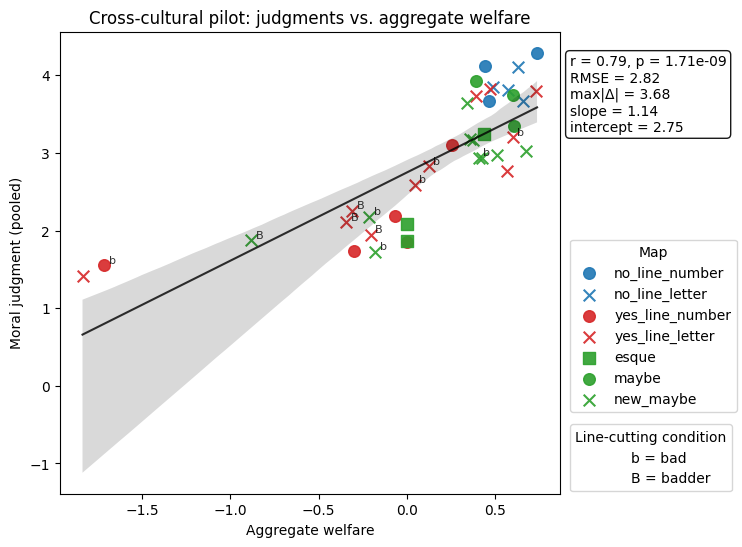

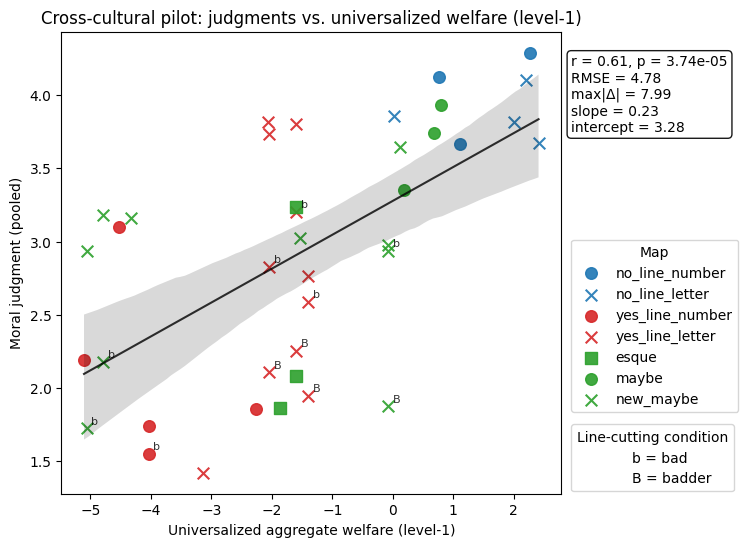

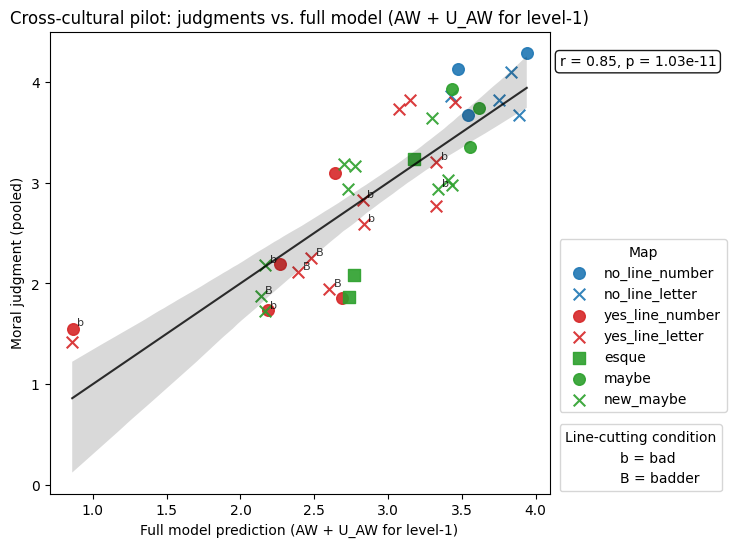

In [30]:
### --- redo for level 1


design1 = design_by_run["level-1"]

models_lvl0 = {}

# M0: AW
row_M0, m_M0 = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M0_AW"] = (row_M0, m_M0)

# M1: AW + U_AW
row_M1, m_M1 = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M1_AW+U_AW"] = (row_M1, m_M1)

# M2a: AW + U_AW + U_Ineq
row_M2a, m_M2a = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_inequality"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M2a_AW+U_AW+U_Ineq"] = (row_M2a, m_M2a)

# M2b: AW + U_AW + U_CH
row_M2b, m_M2b = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_cardinal_harm"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M2b_AW+U_AW+U_CH"] = (row_M2b, m_M2b)

# M2c: AW + U_AW + U_Gini
row_M2c, m_M2c = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_gini"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M2c_AW+U_AW+U_Gini"] = (row_M2c, m_M2c)

# Put rows in a DataFrame
rows = []
for name, (row, model) in models_lvl0.items():
    r = row.copy()
    r["model_id"] = name
    r["logLik"] = model.llf
    rows.append(r)

tbl_lvl0 = pd.DataFrame(rows)

# Add ΔBIC relative to best
best_bic = tbl_lvl0["BIC"].min()
tbl_lvl0["delta_BIC"] = tbl_lvl0["BIC"] - best_bic

# Add LR tests:
# - M0 vs M1
# - M1 vs each M2*
tbl_lvl0["lr_ref"] = None
tbl_lvl0["lr_stat"] = None
tbl_lvl0["lr_df"] = None
tbl_lvl0["lr_p"] = None

def set_lr_row(df, model_from, model_to, ref_name):
    stat, df_lr, p = lr_test(models_lvl0[model_from][1],
                             models_lvl0[model_to][1])
    idx = df["model_id"] == model_to
    df.loc[idx, "lr_ref"] = ref_name
    df.loc[idx, "lr_stat"] = stat
    df.loc[idx, "lr_df"] = df_lr
    df.loc[idx, "lr_p"] = p

# AW vs AW+U_AW
set_lr_row(tbl_lvl0, "M0_AW", "M1_AW+U_AW", ref_name="M0_AW")

# AW+U_AW vs each 3-predictor model
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2a_AW+U_AW+U_Ineq", ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2b_AW+U_AW+U_CH",   ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2c_AW+U_AW+U_Gini", ref_name="M1_AW+U_AW")

# For display: pick columns & order
cols = [
    "model_id",
    "predictors",           # your short labels, e.g. AW+U_AW
    "n_predictors",
    "R2",
    "adj_R2",
    "AIC",
    "BIC",
    "delta_BIC",
    "lr_ref",
    "lr_stat",
    "lr_df",
    "lr_p",
]
tbl_lvl0_display = tbl_lvl0[cols].sort_values("BIC")

# Pull out M0 row
m0 = tbl_lvl0_display[tbl_lvl0_display["model_id"] == "M0_AW"]
rest = tbl_lvl0_display[tbl_lvl0_display["model_id"] != "M0_AW"]

# Recombine with M0 first
tbl_lvl0_display = pd.concat([m0, rest], ignore_index=True)
display(tbl_lvl0_display)

# Add predictions to the design df
design1 = design1.copy()
design1["pred_M0"] = models_lvl0["M0_AW"][1].fittedvalues
design1["pred_M1"] = models_lvl0["M1_AW+U_AW"][1].fittedvalues

#AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design1,
    x_col="aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. aggregate welfare",
    xlabel="Aggregate welfare",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_AW.png",
    display_line_cutting_condition=True,
    fit_regression=True
)

#U_AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design1,
    x_col="univ_aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. universalized welfare (level-1)",
    xlabel="Universalized aggregate welfare (level-1)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_UW_lvl1",
    display_line_cutting_condition=True,
    fit_regression=True
)

# AW + U_AW (do not refit the regressoin; just showing regrssion of y_predicted against y)
fig2, ax2 = plot_simple_regression(
    design1,
    x_col="pred_M1",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. full model (AW + U_AW for level-1)",
    xlabel="Full model prediction (AW + U_AW for level-1)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_full_lvl1",
    display_line_cutting_condition=True,
    fit_regression=False
)



,model_id,predictors,n_predictors,R2,adj_R2,AIC,BIC,delta_BIC,lr_ref,lr_stat,lr_df,lr_p
0,M0_AW,AW,1,0.629469,0.619455,61.299306,64.626429,6.491564,None,None,None,None
1,M1_AW+U_AW,AW+U_AW,2,0.714412,0.698546,53.144180,58.134865,0.000000,M0_AW,10.155126,1,0.001439
2,M2b_AW+U_AW+U_CH,AW+U_AW+U_CH,3,0.730805,0.707731,52.838782,59.493028,1.358163,M1_AW+U_AW,2.305399,1,0.128925
3,M2c_AW+U_AW+U_Gini,AW+U_AW+U_Gini,3,0.722019,0.698192,54.091323,60.745570,2.610704,M1_AW+U_AW,1.052857,1,0.30485
4,M2a_AW+U_AW+U_Ineq,AW+U_AW+U_Ineq,3,0.721530,0.697661,54.159923,60.814170,2.679304,M1_AW+U_AW,0.984257,1,0.32115


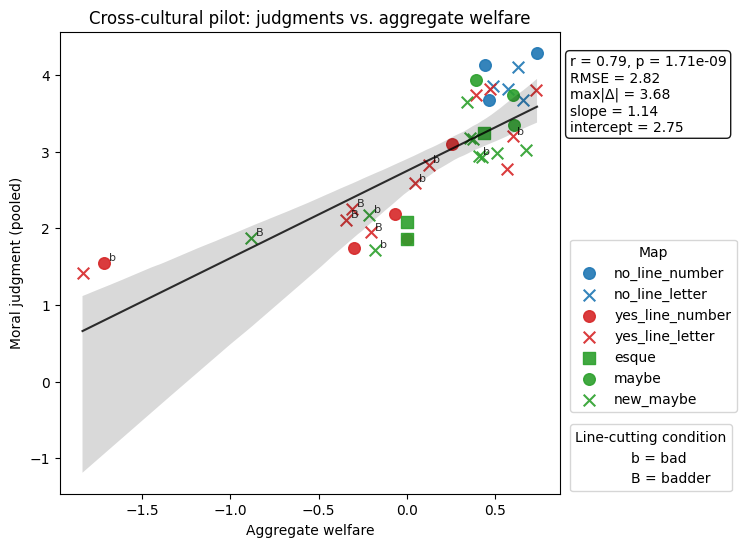

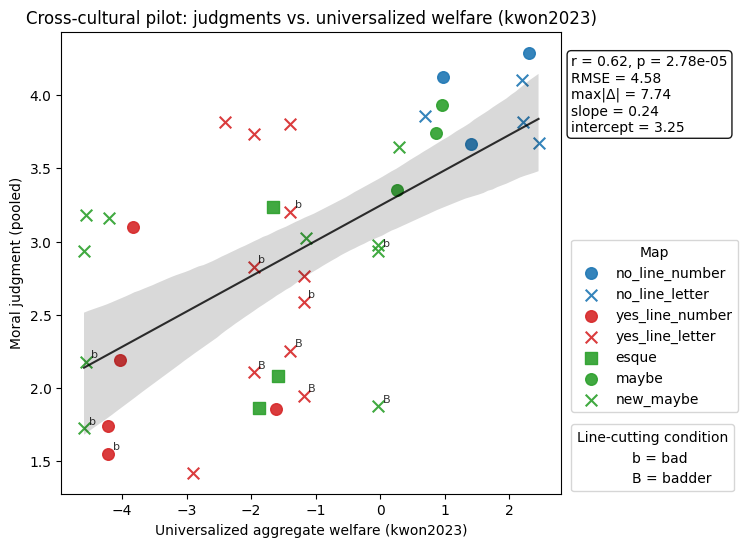

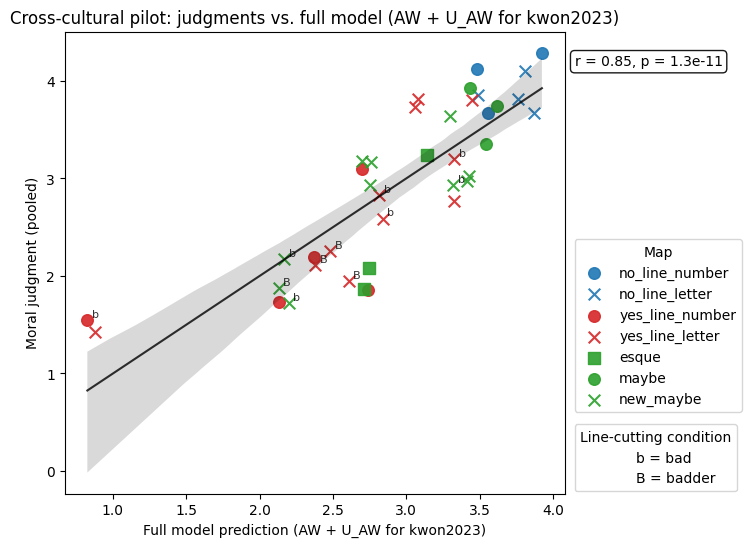

In [26]:
### --- redo for kwon

design1 = design_by_run["kwon2023"]

models_lvl0 = {}

# M0: AW
row_M0, m_M0 = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M0_AW"] = (row_M0, m_M0)

# M1: AW + U_AW
row_M1, m_M1 = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M1_AW+U_AW"] = (row_M1, m_M1)

# M2a: AW + U_AW + U_Ineq
row_M2a, m_M2a = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_inequality"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M2a_AW+U_AW+U_Ineq"] = (row_M2a, m_M2a)

# M2b: AW + U_AW + U_CH
row_M2b, m_M2b = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_cardinal_harm"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M2b_AW+U_AW+U_CH"] = (row_M2b, m_M2b)

# M2c: AW + U_AW + U_Gini
row_M2c, m_M2c = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_gini"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M2c_AW+U_AW+U_Gini"] = (row_M2c, m_M2c)

# Put rows in a DataFrame
rows = []
for name, (row, model) in models_lvl0.items():
    r = row.copy()
    r["model_id"] = name
    r["logLik"] = model.llf
    rows.append(r)

tbl_lvl0 = pd.DataFrame(rows)

# Add ΔBIC relative to best
best_bic = tbl_lvl0["BIC"].min()
tbl_lvl0["delta_BIC"] = tbl_lvl0["BIC"] - best_bic

# Add LR tests:
# - M0 vs M1
# - M1 vs each M2*
tbl_lvl0["lr_ref"] = None
tbl_lvl0["lr_stat"] = None
tbl_lvl0["lr_df"] = None
tbl_lvl0["lr_p"] = None

def set_lr_row(df, model_from, model_to, ref_name):
    stat, df_lr, p = lr_test(models_lvl0[model_from][1],
                             models_lvl0[model_to][1])
    idx = df["model_id"] == model_to
    df.loc[idx, "lr_ref"] = ref_name
    df.loc[idx, "lr_stat"] = stat
    df.loc[idx, "lr_df"] = df_lr
    df.loc[idx, "lr_p"] = p

# AW vs AW+U_AW
set_lr_row(tbl_lvl0, "M0_AW", "M1_AW+U_AW", ref_name="M0_AW")

# AW+U_AW vs each 3-predictor model
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2a_AW+U_AW+U_Ineq", ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2b_AW+U_AW+U_CH",   ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2c_AW+U_AW+U_Gini", ref_name="M1_AW+U_AW")

# For display: pick columns & order
cols = [
    "model_id",
    "predictors",           # your short labels, e.g. AW+U_AW
    "n_predictors",
    "R2",
    "adj_R2",
    "AIC",
    "BIC",
    "delta_BIC",
    "lr_ref",
    "lr_stat",
    "lr_df",
    "lr_p",
]
tbl_lvl0_display = tbl_lvl0[cols].sort_values("BIC")

# Pull out M0 row
m0 = tbl_lvl0_display[tbl_lvl0_display["model_id"] == "M0_AW"]
rest = tbl_lvl0_display[tbl_lvl0_display["model_id"] != "M0_AW"]

# Recombine with M0 first
tbl_lvl0_display = pd.concat([m0, rest], ignore_index=True)
display(tbl_lvl0_display)

# Add predictions to the design df
design1 = design1.copy()
design1["pred_M0"] = models_lvl0["M0_AW"][1].fittedvalues
design1["pred_M1"] = models_lvl0["M1_AW+U_AW"][1].fittedvalues

#AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design1,
    x_col="aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. aggregate welfare",
    xlabel="Aggregate welfare",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_AW.png",
    display_line_cutting_condition=True,
    fit_regression=True
)

#U_AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design1,
    x_col="univ_aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. universalized welfare (kwon2023)",
    xlabel="Universalized aggregate welfare (kwon2023)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_UW_kwon2023",
    display_line_cutting_condition=True,
    fit_regression=True
)

# AW + U_AW (do not refit the regressoin; just showing regrssion of y_predicted against y)
fig2, ax2 = plot_simple_regression(
    design1,
    x_col="pred_M1",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. full model (AW + U_AW for kwon2023)",
    xlabel="Full model prediction (AW + U_AW for kwon2023)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_full_kwon2023",
    display_line_cutting_condition=True,
    fit_regression=False
)

